<a href="https://colab.research.google.com/github/kaorilivia-tech/Calculo-numerico/blob/main/Atividade3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nomes:

Bruno de Carvalho -187107

Livia Kaori Shiba - 185281

Nichollas Lohan - 164928

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import math
import pandas as pd
from IPython.display import Image, display

In [14]:
def f1(x):
  return x**2 - 2

def f2(x) :
  return x**3 - x -2

def f3(x) :
  return np.exp(-x) - x

def f4(x) :
  return x**3 - 2*x + 2

#Derivadas para o método de Newton
def df1(x):
  return 2*x

def df2(x):
  return 3*x**2 - 1

def df3(x):
  return -np.exp(-x)-1

def df4(x):
  return 3*x**2-2



**Método da bisseção**
O intervalo inicial é [a,b] que contenha a raiz e esse intervalo vai diminuindo

In [15]:
def bissecao(f, a, b, tol=1e-6, max_iter=100):

    aproximacoes = []

    fa = f(a)
    fb = f(b)

#Verificação inicial
    if fa * fb > 0:
        return None, 0, aproximacoes, False

    for i in range(1, max_iter + 1):

        m = (a + b) / 2
        fm = f(m)

        aproximacoes.append(m)

#critério de parada
        if abs(fm) < tol:
            return m, i, aproximacoes, True

        if i > 1 and abs(m - aproximacoes[-2]) < tol:
            return m, i, aproximacoes, True

        #Intervalo novo
        if fa * fm < 0:
            b = m
            fb = fm
        else:
            a = m
            fa = fm

    return aproximacoes[-1], max_iter, aproximacoes, False

**Método de newton**

In [16]:
def newton(f, df, x0, tol=1e-6, max_iter=100):

    aproximacoes = [x0]

    for i in range(1, max_iter + 1):

        derivada = df(x0)

#Evita divisão por zero
        if abs(derivada) < 1e-12:
            return x0, i-1, aproximacoes, False

        x1 = x0 - f(x0) / derivada

        aproximacoes.append(x1)

#Critério de parada
        if abs(x1 - x0) < tol and abs(f(x1)) < tol:
            return x1, i, aproximacoes, True

        x0 = x1

    return aproximacoes[-1], max_iter, aproximacoes, False

**Método da secante**

In [17]:
def secante(f, x0, x1, tol=1e-6, max_iter=100):

    aproximacoes = [x0, x1]

    for i in range(1, max_iter + 1):

        denominador = f(x1) - f(x0)

#Evita divisão por zero
        if abs(denominador) < 1e-12:
            return x1, i-1, aproximacoes, False

        x2 = x1 - f(x1) * (x1 - x0) / denominador

        aproximacoes.append(x2)

#Critério de parada
        if abs(x2 - x1) < tol and abs(f(x2)) < tol:
            return x2, i, aproximacoes, True

        x0 = x1
        x1 = x2

    return aproximacoes[-1], max_iter, aproximacoes, False

**Valores iniciais**

In [18]:
funcoes = {
    "f1": {
        "f": f1,
        "df": df1,
        "intervalo": (1, 2),
        "newton": 1.5,
        "secante": (1, 2)
    },

    "f2": {
        "f": f2,
        "df": df2,
        "intervalo": (1, 2),
        "newton": 1.5,
        "secante": (1, 2)
    },

    "f3": {
        "f": f3,
        "df": df3,
        "intervalo": (0, 1),
        "newton": 0.5,
        "secante": (0, 1)
    },

    "f4": {
        "f": f4,
        "df": df4,
        "intervalo": (-2, -1),
        "newton": -2,
        "secante": (-2, -1)
    }
}

**Testando tudo**

In [19]:
resultados = []

tol = 1e-6
max_iter = 100

for nome, dados in funcoes.items():

    f = dados["f"]
    df = dados["df"]

#Bisseção
    a, b = dados["intervalo"]

    raiz, it, aprox, convergiu = bissecao(
        f, a, b, tol, max_iter
    )

    resultados.append([
        nome,
        "Bisseção",
        f"[{a}, {b}]",
        raiz,
        abs(f(raiz)),
        it,
        "Convergiu" if convergiu else "Falhou"
    ])


#Newton
    x0 = dados["newton"]

    raiz, it, aprox, convergiu = newton(
        f, df, x0, tol, max_iter
    )

    resultados.append([
        nome,
        "Newton",
        f"x0 = {x0}",
        raiz,
        abs(f(raiz)),
        it,
        "Convergiu" if convergiu else "Falhou"
    ])


#Secante
    x0, x1 = dados["secante"]

    raiz, it, aprox, convergiu = secante(
        f, x0, x1, tol, max_iter
    )

    resultados.append([
        nome,
        "Secante",
        f"({x0}, {x1})",
        raiz,
        abs(f(raiz)),
        it,
        "Convergiu" if convergiu else "Falhou"
    ])

**Tabela**

In [20]:
tabela = pd.DataFrame(
    resultados,
    columns=[
        "Função",
        "Método",
        "Valores iniciais",
        "Raiz aproximada",
        "|f(x)| final",
        "Iterações",
        "Resultado"
    ]
)

tabela

,Função,Método,Valores iniciais,Raiz aproximada,|f(x)| final,Iterações,Resultado
0,f1,Bisseção,"[1, 2]",1.414214,1.617417e-06,20,Convergiu
1,f1,Newton,x0 = 1.5,1.414214,4.440892e-16,4,Convergiu
2,f1,Secante,"(1, 2)",1.414214,8.881784e-16,6,Convergiu
3,f2,Bisseção,"[1, 2]",1.521380,4.265829e-06,20,Convergiu
4,f2,Newton,x0 = 1.5,1.521380,4.529710e-14,3,Convergiu
5,f2,Secante,"(1, 2)",1.521380,1.842970e-14,7,Convergiu
6,f3,Bisseção,"[0, 1]",0.567143,2.348157e-07,20,Convergiu
7,f3,Newton,x0 = 0.5,0.567143,4.440892e-15,3,Convergiu
8,f3,Secante,"(0, 1)",0.567143,1.242340e-13,5,Convergiu
9,f4,Bisseção,"[-2, -1]",-1.769292,3.521840e-06,20,Convergiu


**Animação**

In [21]:
def bissecao_animacao(f, a, b, tol=1e-6, max_iter=100):

    aproximacoes = []
    intervalos = []

    fa = f(a)

    for i in range(max_iter):

        m = (a + b) / 2
        fm = f(m)

        aproximacoes.append(m)
        intervalos.append((a, b))

        if abs(fm) < tol:
            break

        if fa * fm < 0:
            b = m
        else:
            a = m
            fa = fm

    return aproximacoes, intervalos



def animar_bissecao(f, a, b, nome_arquivo):

    aproximacoes, intervalos = bissecao_animacao(
        f, a, b
    )

    x = np.linspace(a - 0.2, b + 0.2, 500)

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(
        min(f(x)) - 1,
        max(f(x)) + 1
    )

    ax.axhline(0)

    curva, = ax.plot(x, f(x))
    ponto, = ax.plot([], [], 'o')

    linha_a, = ax.plot([], [], '--')
    linha_b, = ax.plot([], [], '--')

    texto = ax.text(
        0.02, 0.95,
        "",
        transform=ax.transAxes,
        verticalalignment='top'
    )

    def atualizar(i):

        m = aproximacoes[i]
        a_i, b_i = intervalos[i]

        ponto.set_data([m], [f(m)])

        linha_a.set_data(
            [a_i, a_i],
            [0, f(a_i)]
        )

        linha_b.set_data(
            [b_i, b_i],
            [0, f(b_i)]
        )

        texto.set_text(
            f"Iteração: {i+1}\n"
            f"x = {m:.8f}\n"
            f"|f(x)| = {abs(f(m)):.2e}"
        )

        return ponto, linha_a, linha_b, texto

    animacao = FuncAnimation(
        fig,
        atualizar,
        frames=len(aproximacoes),
        interval=500,
        blit=True
    )

    animacao.save(
        nome_arquivo,
        writer=PillowWriter(fps=2)
    )

    plt.close()

**Animação de Newton**

In [22]:
def animar_newton(f, df, x0, nome_arquivo):

    raiz, it, aproximacoes, convergiu = newton(
        f, df, x0
    )

    x_min = min(aproximacoes) - 1
    x_max = max(aproximacoes) + 1

    x = np.linspace(x_min, x_max, 500)

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(x, f(x))
    ax.axhline(0)

    ponto, = ax.plot([], [], 'o')
    tangente, = ax.plot([], [], '--')

    texto = ax.text(
        0.02, 0.95,
        "",
        transform=ax.transAxes,
        verticalalignment='top'
    )

    def atualizar(i):

        xi = aproximacoes[i]

        # ponto atual
        ponto.set_data(
            [xi],
            [f(xi)]
        )

        # reta tangente
        d = df(xi)

        y_tangente = (
            f(xi) + d * (x - xi)
        )

        tangente.set_data(
            x,
            y_tangente
        )

        texto.set_text(
            f"Iteração: {i}\n"
            f"x = {xi:.8f}\n"
            f"|f(x)| = {abs(f(xi)):.2e}"
        )

        return ponto, tangente, texto

    animacao = FuncAnimation(
        fig,
        atualizar,
        frames=len(aproximacoes),
        interval=700,
        blit=True
    )

    animacao.save(
        nome_arquivo,
        writer=PillowWriter(fps=2)
    )

    plt.close()

**Animação da secante**

In [23]:
def animar_secante(f, x0, x1, nome_arquivo):

    raiz, it, aproximacoes, convergiu = secante(
        f, x0, x1
    )

    x_min = min(aproximacoes) - 1
    x_max = max(aproximacoes) + 1

    x = np.linspace(x_min, x_max, 500)

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(x, f(x))
    ax.axhline(0)

    pontos, = ax.plot([], [], 'o')
    reta, = ax.plot([], [], '--')

    texto = ax.text(
        0.02, 0.95,
        "",
        transform=ax.transAxes,
        verticalalignment='top'
    )

    def atualizar(i):

#precisamos de dois pontos
        if i == 0:
            xa = aproximacoes[0]
            xb = aproximacoes[1]
        else:
            xa = aproximacoes[i]
            xb = aproximacoes[i+1]

        ya = f(xa)
        yb = f(xb)

        pontos.set_data(
            [xa, xb],
            [ya, yb]
        )

#coeficiente angular
        m = (yb - ya) / (xb - xa)

#reta secante
        y_reta = ya + m * (x - xa)

        reta.set_data(
            x,
            y_reta
        )

        texto.set_text(
            f"Iteração: {i+1}\n"
            f"x = {xb:.8f}\n"
            f"|f(x)| = {abs(f(xb)):.2e}"
        )

        return pontos, reta, texto

    frames = len(aproximacoes) - 1

    animacao = FuncAnimation(
        fig,
        atualizar,
        frames=frames,
        interval=700,
        blit=True
    )

    animacao.save(
        nome_arquivo,
        writer=PillowWriter(fps=2)
    )

    plt.close()

**Gerando Gifs**

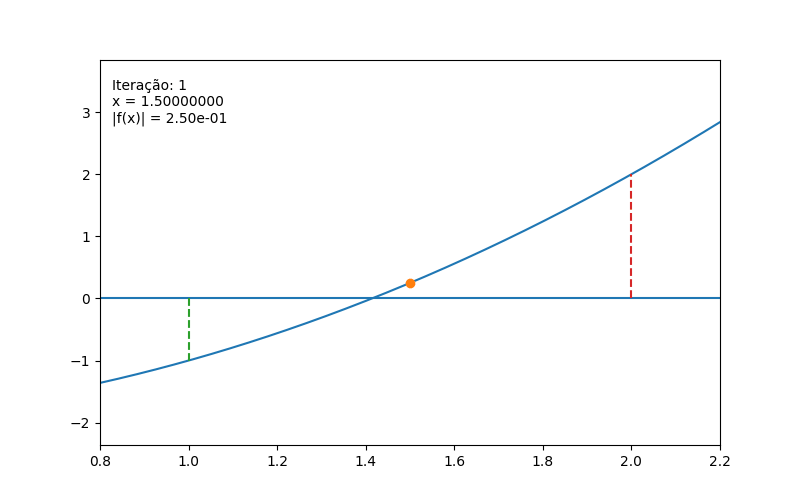

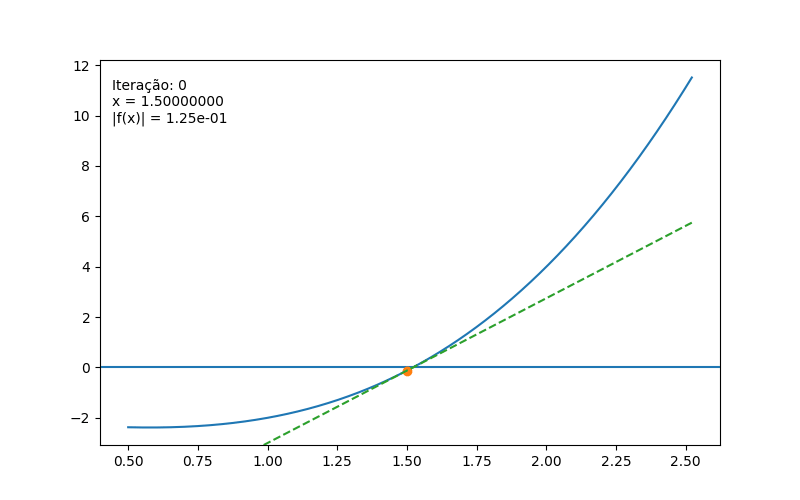

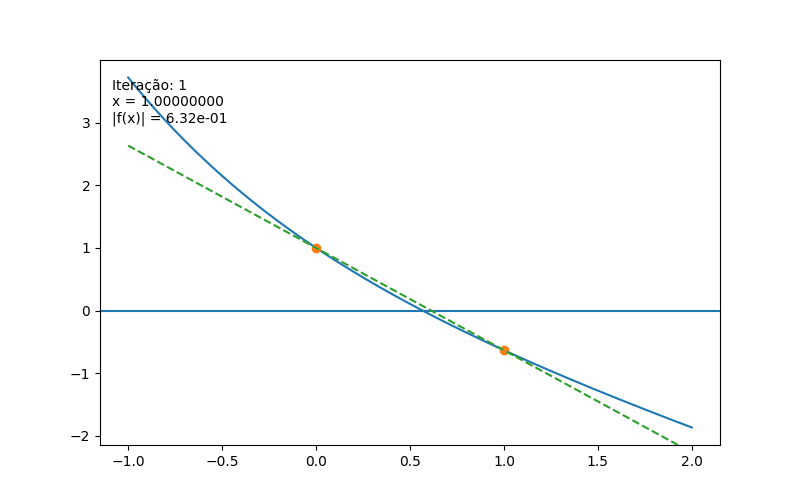

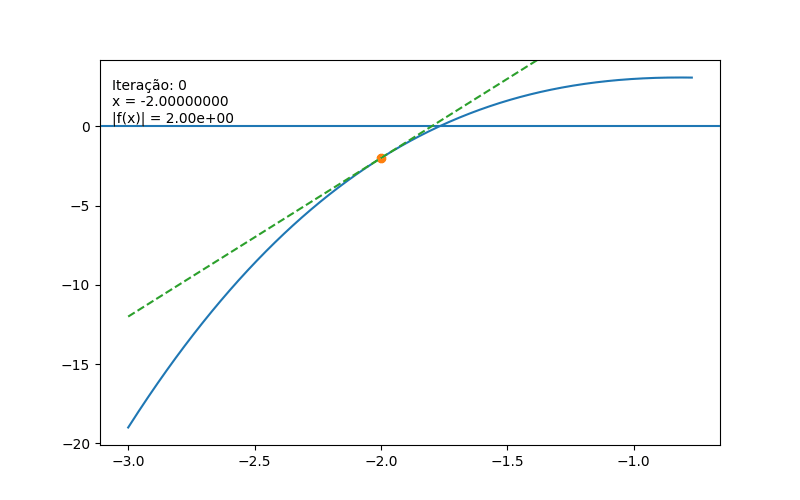

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
#GIF 1- bisseção
animar_bissecao(
    f1,
    1,
    2,
    "bissecao_f1.gif"
)

display(Image(filename="bissecao_f1.gif"))

#Gif 2- Newton

animar_newton(
    f2,
    df2,
    1.5,
    "newton_f2.gif"
)

display(Image(filename="newton_f2.gif"))

#GIF 3- secante

animar_secante(
    f3,
    0,
    1,
    "secante_f3.gif"
)

display(Image(filename="secante_f3.gif"))


#GIF 4- newton 2

animar_newton(
    f4,
    df4,
    -2,
    "newton_f4.gif"
)

display(Image(filename="newton_f4.gif"))

from google.colab import files

files.download("bissecao_f1.gif")
files.download("newton_f2.gif")
files.download("secante_f3.gif")
files.download("newton_f4.gif")

## 5. Análise dos resultados

- **Todos os métodos convergiram** para os valores iniciais sugeridos:
  $f_1$: $\sqrt 2 \approx 1{,}41421356$; $f_2$: $\approx 1{,}52137971$; $f_3$: $\approx 0{,}56714329$; $f_4$: $\approx -1{,}76929235$.
- **Bisseção** foi sempre o mais lento (≈ 20 iterações), pois o erro cai só pela metade a cada passo
  (convergência linear, $\frac{b-a}{2^k} < 10^{-6} \Rightarrow k \approx 20$). Em compensação, **sempre converge**
  quando $f(a)f(b)<0$ e $f$ é contínua.
- **Newton** foi o mais rápido (2–4 iterações), graças à convergência **quadrática**: o número de casas
  corretas praticamente dobra a cada iteração. Porém exige a derivada e depende muito de $x_0$:
  em $f_4$ com $x_0 = 0$ ele fica preso no ciclo $0 \to 1 \to 0$ e falha após 100 iterações;
  com $x_0$ onde $f'(x_0)=0$ ele nem consegue dar o primeiro passo.
- **Secante** ficou entre os dois (4–6 iterações, ordem ≈ 1,618) e não precisa da derivada,
  mas, como Newton, não tem garantia de convergência e pode falhar se $f(x_k) \approx f(x_{k-1})$.
- Os resíduos $|f(x)|$ finais ficaram abaixo de $10^{-6}$ (em Newton/secante, muitas vezes bem abaixo, pela
  convergência rápida no último passo).

**Conclusão:** a bisseção é robusta porém lenta; Newton é o mais rápido, mas sensível ao chute inicial e
precisa de $f'$; a secante é um bom meio-termo. Na prática, é comum usar a bisseção para aproximar a raiz
e depois refinar com Newton ou secante.